# Avaliação de dificuldade das questões (Fase 3) via modelos Ollama

Este notebook estima a **dificuldade empírica** das 102 questões geradas na
`fase_3` fazendo **3 modelos locais via [Ollama](https://ollama.com)**
responderem cada uma delas (sem ver o gabarito) e comparando com a resposta
correta.

**Regra de classificação** (conforme definido para esta análise):

| Nº de modelos que acertam | Dificuldade estimada |
|---|---|
| 3 de 3 | 🟢 Fácil |
| 2 de 3 | 🟡 Média |
| 0 ou 1 de 3 | 🔴 Difícil |

> A regra original só especificava os casos de 3, 2 e 0 acertos. Aqui o caso
> de **1 acerto** foi agrupado com "0 acertos" em **Difícil**, por não haver
> maioria de modelos acertando a questão. Se preferir outro critério, ajuste
> a função `classificar_dificuldade` mais abaixo — o resto do notebook não
> precisa mudar.

## Modelos avaliados

- `qwen2.5:7b-instruct`
- `phi4-mini:latest`
- `llama3.2:3b`

## Pré-requisitos

1. **Ollama instalado e rodando localmente** (`ollama serve`), acessível em
   `http://localhost:11434` (ajustável em `OLLAMA_HOST` abaixo).
2. Os 3 modelos já baixados:
   ```bash
   ollama pull qwen2.5:7b-instruct
   ollama pull phi4-mini:latest
   ollama pull llama3.2:3b
   ```
3. Pacotes Python: `pandas`, `matplotlib`, `requests`, `tqdm`
   (`pip install pandas matplotlib requests tqdm` se necessário).

## ⏱️ Tempo esperado

São **102 questões × 3 modelos = 306 chamadas**. Rodando em CPU (sem GPU),
cada chamada leva tipicamente entre 10s e 60s dependendo do tamanho do
modelo — ou seja, a avaliação completa pode levar de **1 a 4+ horas**. Com
GPU costuma ser bem mais rápido (segundos por chamada).

A célula de avaliação salva cada resposta em um checkpoint (`.jsonl`) assim
que ela é obtida — então o notebook pode ser **interrompido e retomado** a
qualquer momento sem perder o progresso já feito (reexecutar a célula pula
o que já foi respondido).


In [20]:
import json
import re
import time
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
from tqdm.auto import tqdm

pd.set_option("display.max_colwidth", 120)


## Configuração

In [21]:
# --- Caminhos -----------------------------------------------------------
QUESTOES_PATH = Path("../saida_fase3/repositorio/questoes.jsonl")

OUT_DIR = Path("resultados_dificuldade")
OUT_DIR.mkdir(exist_ok=True)
CHARTS_DIR = OUT_DIR / "graficos"
CHARTS_DIR.mkdir(exist_ok=True)

CHECKPOINT_PATH = OUT_DIR / "respostas_ollama.jsonl"       # 1 linha por (questão, modelo)
RESULTADOS_CSV = OUT_DIR / "resultados_dificuldade_fase3.csv"
# pipeline/fase_3/saida_fase3/repositorio/questoes.jsonl
# --- Ollama ---------------------------------------------------------------
OLLAMA_HOST = "http://localhost:11434"

# Ordem fixa (também define a cor de cada modelo nos gráficos)
MODELS = [
    "gemma2:2b",
    "phi4-mini:latest",
    "llama3.2:3b",
]

TEMPERATURE = 0.0     # determinístico
NUM_PREDICT = 16      # resposta é só "RESPOSTA: <letra>", não precisa de mais tokens
TIMEOUT_S = 180        # timeout por chamada (modelos maiores em CPU podem demorar)
MAX_RETRIES = 3

# Defina um inteiro (ex.: 5) para testar rápido com poucas questões antes de
# rodar tudo; None = usa as 102 questões.
SAMPLE_SIZE = None
RANDOM_SEED = 42

# Paleta fixa por modelo (mesma ordem de MODELS, consistente em todos os gráficos)
MODEL_COLORS = {
    "gemma2:2b": "#2a78d6",  # azul
    "phi4-mini:latest": "#eb6834",     # laranja
    "llama3.2:3b": "#1baf7a",          # água
}

# Paleta por dificuldade (semântica: bom/atenção/crítico)
DIFF_COLORS = {"Fácil": "#0ca30c", "Média": "#fab219", "Difícil": "#d03b3b"}
DIFF_ORDER = ["Fácil", "Média", "Difícil"]

INK = "#0b0b0b"
INK_MUTED = "#898781"
GRID = "#e1e0d9"


## Carregar as questões da fase 3

In [22]:
with open(QUESTOES_PATH, encoding="utf-8") as f:
    questoes = [json.loads(l) for l in f if l.strip()]

if SAMPLE_SIZE:
    import random
    random.seed(RANDOM_SEED)
    questoes = random.sample(questoes, min(SAMPLE_SIZE, len(questoes)))

print(f"{len(questoes)} questões carregadas de {QUESTOES_PATH}")
questoes[0]["stem"][:200]


56 questões carregadas de ..\saida_fase3\repositorio\questoes.jsonl


'Em um retrofit do sistema de offloading de um FPSO, considera-se trocar a conexão flangeada entre a linha de transferência e o mangote por um acoplamento BLS com interface NSV. Buscando reduzir proble'

## Funções auxiliares: prompt, chamada ao Ollama e leitura da resposta

In [23]:
LETTERS = ["A", "B", "C", "D", "E", "F"]


def build_prompt(q: dict) -> str:
    """Monta o prompt de múltipla escolha (o modelo não vê o gabarito)."""
    alternativas = "\n".join(
        f"{LETTERS[i]}) {alt}" for i, alt in enumerate(q["alternatives"])
    )
    return (
        "Você é um especialista técnico respondendo uma questão de múltipla escolha.\n"
        "Leia o enunciado e as alternativas e escolha a única alternativa correta.\n"
        "Responda EXATAMENTE no formato abaixo, sem nenhum texto antes ou depois:\n"
        "RESPOSTA: <letra>\n\n"
        f"Enunciado: {q['stem']}\n\n{alternativas}\n\n"
        "RESPOSTA:"
    )


def parse_letter(text: str, n_alt: int) -> str | None:
    """Extrai a letra da resposta de forma tolerante a variações do modelo."""
    if not text:
        return None
    letters = "ABCDEF"[:n_alt]
    m = re.search(rf"RESPOSTA[:\s]*\(?([{letters}])\)?", text, re.IGNORECASE)
    if m:
        return m.group(1).upper()
    m = re.match(rf"^\s*\(?([{letters}])\)?[\.\):]?\s*$", text.strip())
    if m:
        return m.group(1).upper()
    tokens = re.findall(rf"(?<![A-Za-z])([{letters}])(?![A-Za-z])", text)
    return tokens[-1].upper() if tokens else None


def call_ollama(model: str, prompt: str) -> str:
    """Chama /api/generate com retries; devolve o texto bruto da resposta."""
    last_err = None
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            r = requests.post(
                f"{OLLAMA_HOST}/api/generate",
                json={
                    "model": model,
                    "prompt": prompt,
                    "stream": False,
                    "options": {"temperature": TEMPERATURE, "num_predict": NUM_PREDICT},
                },
                timeout=TIMEOUT_S,
            )
            r.raise_for_status()
            return r.json().get("response", "")
        except Exception as e:  # noqa: BLE001
            last_err = e
            time.sleep(2 * attempt)
    raise RuntimeError(f"Falha ao chamar {model} após {MAX_RETRIES} tentativas: {last_err}")


## Verificação de conectividade com o Ollama

In [24]:
def checar_ollama():
    try:
        r = requests.get(f"{OLLAMA_HOST}/api/tags", timeout=10)
        r.raise_for_status()
    except Exception as e:  # noqa: BLE001
        raise RuntimeError(
            f"Não consegui falar com o Ollama em {OLLAMA_HOST}. "
            f"Confirme que 'ollama serve' está rodando. Erro: {e}"
        )
    disponiveis = {m["name"] for m in r.json().get("models", [])}
    faltando = [m for m in MODELS if m not in disponiveis]
    print(f"Ollama OK em {OLLAMA_HOST}. Modelos instalados: {sorted(disponiveis)}")
    if faltando:
        comandos = "\n".join(f"  ollama pull {m}" for m in faltando)
        raise RuntimeError(
            "Faltam modelos necessários para esta avaliação. Rode:\n" + comandos
        )
    print("Todos os modelos necessários estão disponíveis. ✅")


checar_ollama()

Ollama OK em http://localhost:11434. Modelos instalados: ['deepseek-r1:7b', 'deepseek-r1:8b', 'gemma2:27b', 'gemma2:2b', 'gemma3:12b', 'llama3.1:8b', 'llama3.1:latest', 'llama3.2:3b', 'nomic-embed-text:latest', 'phi3:medium', 'phi3:mini', 'phi4-mini:latest', 'phi4-reasoning:latest', 'phi:latest', 'qwen2.5:32b', 'qwen2.5:7b', 'qwen2.5:7b-instruct']
Todos os modelos necessários estão disponíveis. ✅


## Rodar a avaliação (com checkpoint)

Cada resposta é salva em `resultados_dificuldade/respostas_ollama.jsonl`
assim que é obtida. Se essa célula for interrompida, basta rodá-la de novo:
ela pula os pares (questão, modelo) que já estão no checkpoint.

In [25]:
def carregar_checkpoint() -> dict:
    """{(question_id, model): registro}"""
    feito = {}
    if CHECKPOINT_PATH.exists():
        with open(CHECKPOINT_PATH, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                rec = json.loads(line)
                feito[(rec["id"], rec["model"])] = rec
    return feito


feito = carregar_checkpoint()
print(f"{len(feito)} respostas já registradas no checkpoint.")

pendentes = [
    (q, m) for q in questoes for m in MODELS if (q["id"], m) not in feito
]
print(f"{len(pendentes)} chamadas pendentes de {len(questoes) * len(MODELS)} totais.")

with open(CHECKPOINT_PATH, "a", encoding="utf-8") as f_out:
    for q, model in tqdm(pendentes, desc="Consultando modelos"):
        prompt = build_prompt(q)
        try:
            raw = call_ollama(model, prompt)
        except RuntimeError as e:
            print(f"[ERRO] questão {q['id']} / {model}: {e}")
            continue
        letra = parse_letter(raw, len(q["alternatives"]))
        gold = LETTERS[q["correct_answer_index"]]
        rec = {
            "id": q["id"],
            "model": model,
            "raw_response": raw,
            "predicted_letter": letra,
            "gold_letter": gold,
            "correct": letra == gold,
        }
        f_out.write(json.dumps(rec, ensure_ascii=False) + "\n")
        f_out.flush()
        feito[(q["id"], model)] = rec

print("Avaliação concluída (ou já estava completa).")


168 respostas já registradas no checkpoint.
56 chamadas pendentes de 168 totais.


Consultando modelos:   0%|          | 0/56 [00:00<?, ?it/s]

Avaliação concluída (ou já estava completa).


## Consolidar resultados e estimar a dificuldade

In [26]:
def classificar_dificuldade(n_corretos: int, n_modelos: int) -> str:
    """3/3 corretos -> Fácil · 2/3 -> Média · 0 ou 1/3 -> Difícil."""
    if n_corretos == n_modelos:
        return "Fácil"
    if n_corretos == n_modelos - 1:
        return "Média"
    return "Difícil"


registros = list(feito.values())
resp_df = pd.DataFrame(registros)

faltando_resp = resp_df[resp_df["predicted_letter"].isna()]
if len(faltando_resp):
    print(f"Aviso: {len(faltando_resp)} respostas não puderam ser lidas (predicted_letter nulo).")

# tabela questão x modelo (True/False)
pivot_correct = resp_df.pivot_table(
    index="id", columns="model", values="correct", aggfunc="first"
)[MODELS]

n_modelos = len(MODELS)
n_corretos = pivot_correct.sum(axis=1)
dificuldade_estimada = n_corretos.apply(lambda n: classificar_dificuldade(n, n_modelos))

meta = pd.DataFrame(questoes).set_index("id")[
    ["topico", "subtopico", "difficulty", "nota", "stem", "correct_answer_index"]
].rename(columns={"difficulty": "dificuldade_fase3"})

DIFF_LABEL = {"facil": "Fácil", "media": "Média", "dificil": "Difícil"}
meta["dificuldade_fase3"] = meta["dificuldade_fase3"].map(DIFF_LABEL).fillna(meta["dificuldade_fase3"])

resultado = meta.join(pivot_correct).join(
    n_corretos.rename("n_modelos_corretos")
).join(dificuldade_estimada.rename("dificuldade_estimada"))

resultado["dificuldade_estimada"] = pd.Categorical(
    resultado["dificuldade_estimada"], categories=DIFF_ORDER, ordered=True
)

resultado.to_csv(RESULTADOS_CSV, encoding="utf-8")
print(f"Resultado consolidado salvo em {RESULTADOS_CSV}")
resultado.head()


Resultado consolidado salvo em resultados_dificuldade\resultados_dificuldade_fase3.csv


,topico,subtopico,dificuldade_fase3,nota,stem,correct_answer_index,gemma2:2b,phi4-mini:latest,llama3.2:3b,n_modelos_corretos,dificuldade_estimada
id,,,,,,,,,,,
80d9d9002a-f0-d0-r11-q0,Produção e Processo (Medição Fiscal e Sistema de Alívio),"Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações de offloading",Média,0.91,"Em um retrofit do sistema de offloading de um FPSO, considera-se trocar a conexão flangeada entre a linha de transfe...",0,True,True,False,2,Média
80d9d9002a-f0-d0-r11-q1,Produção e Processo (Medição Fiscal e Sistema de Alívio),"Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações de offloading",Média,0.93,"Em testes de comissionamento da linha de offloading, verificou-se que, após o deslocamento, permanece água residual ...",0,True,True,True,3,Fácil
80d9d9002a-f0-d0-r11-q2,Produção e Processo (Medição Fiscal e Sistema de Alívio),"Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações de offloading",Média,0.88,"Em um FPSO, a engenharia deve especificar a medição fiscal de duas correntes: óleo na linha de offloading, com água ...",3,True,True,True,3,Fácil
80d9d9002a-f0-d0-r11-q3,Produção e Processo (Medição Fiscal e Sistema de Alívio),"Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações de offloading",Difícil,0.91,"Na análise operacional de uma linha de offloading, simulações indicam que aumentar a vazão de deslocamento eleva o r...",1,True,False,False,1,Difícil
80d9d9002a-f0-d0-r11-q4,Produção e Processo (Medição Fiscal e Sistema de Alívio),"Medição Fiscal de óleo, medição fiscal de gás e transferência de custódia em operações de offloading",Média,0.90,Uma linha de transferência com trechos de difícil acesso passou a apresentar desvios graduais entre volumes fiscais ...,1,True,True,True,3,Fácil


## Gráficos

Convenções usadas em todos os gráficos: cada modelo mantém sempre a mesma
cor; verde/âmbar/vermelho identificam Fácil/Média/Difícil (com rótulos de
valor, nunca só a cor).

In [27]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": INK,
    "ytick.color": INK,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def limpar_eixos(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)


### 1. Acurácia geral por modelo

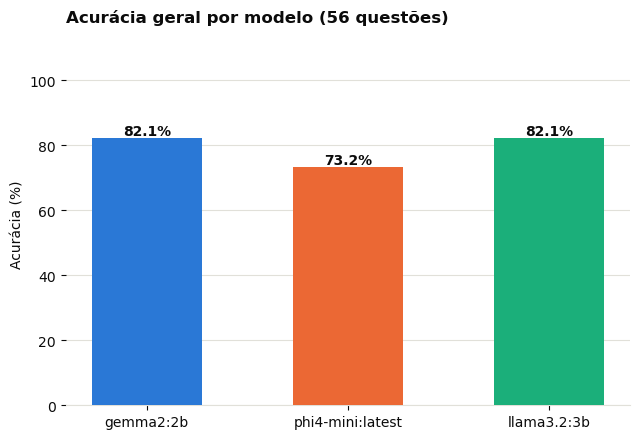

In [28]:
acc_geral = resultado[MODELS].mean().reindex(MODELS) * 100

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(
    range(len(MODELS)), acc_geral.values,
    color=[MODEL_COLORS[m] for m in MODELS], width=0.55, zorder=3,
)
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(MODELS, rotation=0)
ax.set_ylim(0, 112)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_ylabel("Acurácia (%)")
ax.set_title(f"Acurácia geral por modelo ({len(resultado)} questões)", loc="left", fontweight="bold", pad=14)
limpar_eixos(ax)
for b, v in zip(bars, acc_geral.values):
    ax.annotate(f"{v:.1f}%", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                fontsize=10, color=INK, fontweight="bold")
fig.tight_layout()
fig.savefig(CHARTS_DIR / "01_acuracia_geral_por_modelo.png", dpi=150)
plt.show()


### 2. Acurácia por modelo dentro de cada tópico

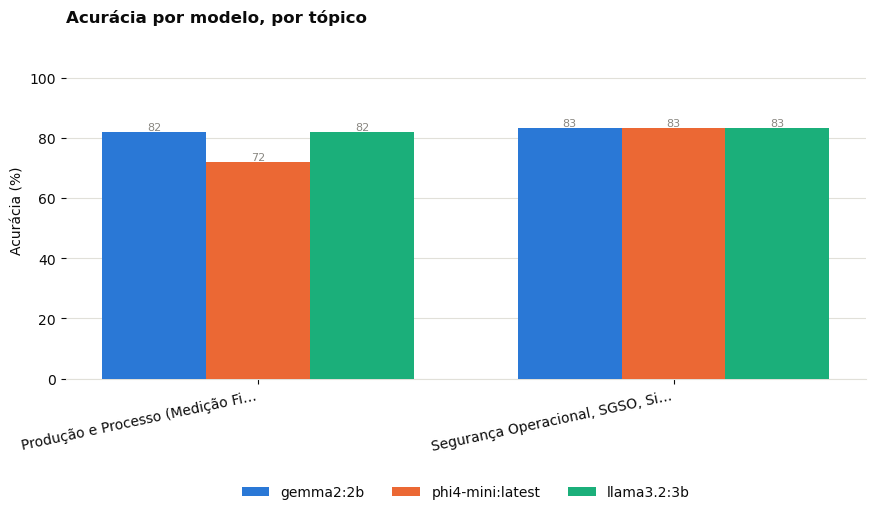

In [29]:
acc_topico = (
    resultado.groupby("topico")[MODELS].mean().reindex(columns=MODELS) * 100
)
topicos = list(acc_topico.index)

fig, ax = plt.subplots(figsize=(9, 5.5))
x = range(len(topicos))
width = 0.25
for i, m in enumerate(MODELS):
    xs = [xi + (i - 1) * width for xi in x]
    bars = ax.bar(xs, acc_topico[m].values, width=width, color=MODEL_COLORS[m], label=m, zorder=3)
    for b, v in zip(bars, acc_topico[m].values):
        ax.annotate(f"{v:.0f}", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                    fontsize=8, color=INK_MUTED)

ax.set_xticks(list(x))
ax.set_xticklabels([t if len(t) < 34 else t[:31] + "…" for t in topicos], rotation=12, ha="right")
ax.set_ylim(0, 112)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_ylabel("Acurácia (%)")
ax.set_title("Acurácia por modelo, por tópico", loc="left", fontweight="bold", pad=14)
limpar_eixos(ax)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=3)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "02_acuracia_por_topico.png", dpi=150)
plt.show()


### 3. Distribuição da dificuldade estimada (quantas questões em cada nível)

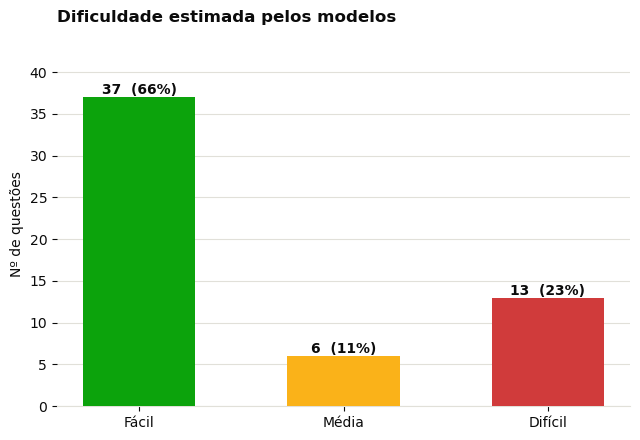

In [30]:
contagem_dif = resultado["dificuldade_estimada"].value_counts().reindex(DIFF_ORDER).fillna(0)
pct_dif = contagem_dif / contagem_dif.sum() * 100

fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(DIFF_ORDER, contagem_dif.values, color=[DIFF_COLORS[d] for d in DIFF_ORDER], width=0.55, zorder=3)
ax.set_ylim(0, max(contagem_dif.values.max(), 1) * 1.18)
ax.set_ylabel("Nº de questões")
ax.set_title("Dificuldade estimada pelos modelos", loc="left", fontweight="bold", pad=14)
limpar_eixos(ax)
for b, v, p in zip(bars, contagem_dif.values, pct_dif.values):
    ax.annotate(f"{int(v)}  ({p:.0f}%)", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                fontsize=10, color=INK, fontweight="bold")
fig.tight_layout()
fig.savefig(CHARTS_DIR / "03_distribuicao_dificuldade_estimada.png", dpi=150)
plt.show()


### 4. Dificuldade estimada (modelos) vs. dificuldade original (fase 3)

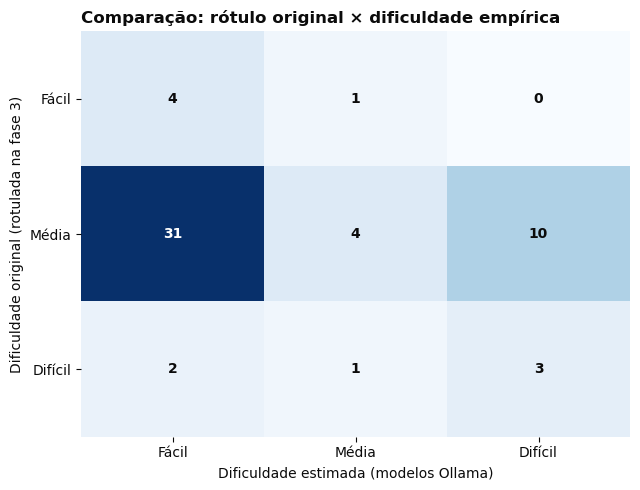

In [31]:
fase3_order = [d for d in DIFF_ORDER if d in resultado["dificuldade_fase3"].unique()]
crosstab = pd.crosstab(resultado["dificuldade_fase3"], resultado["dificuldade_estimada"])
crosstab = crosstab.reindex(index=fase3_order, columns=DIFF_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(crosstab.values, cmap="Blues", aspect="auto", vmin=0)
ax.set_xticks(range(len(DIFF_ORDER)))
ax.set_xticklabels(DIFF_ORDER)
ax.set_yticks(range(len(fase3_order)))
ax.set_yticklabels(fase3_order)
ax.set_xlabel("Dificuldade estimada (modelos Ollama)")
ax.set_ylabel("Dificuldade original (rotulada na fase 3)")
ax.set_title("Comparação: rótulo original × dificuldade empírica", loc="left", fontweight="bold")

vmax = crosstab.values.max() if crosstab.values.size else 1
for i in range(crosstab.shape[0]):
    for j in range(crosstab.shape[1]):
        v = crosstab.values[i, j]
        cor_txt = "white" if v > vmax * 0.6 else INK
        ax.text(j, i, str(v), ha="center", va="center", color=cor_txt, fontweight="bold")

for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "04_comparacao_dificuldade_original_vs_estimada.png", dpi=150)
plt.show()


### 5. Acurácia por modelo, segmentada pela dificuldade original da fase 3

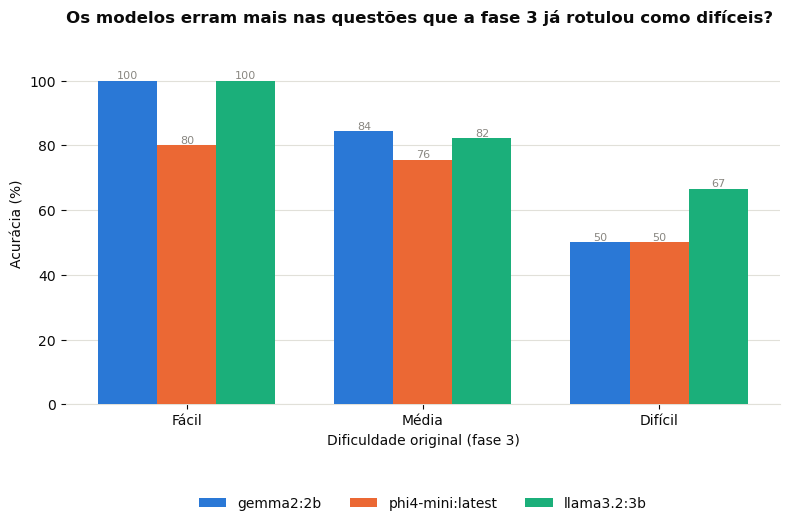

In [32]:
acc_por_dif_original = (
    resultado.groupby("dificuldade_fase3")[MODELS].mean().reindex(fase3_order, columns=MODELS) * 100
)

fig, ax = plt.subplots(figsize=(8, 5.5))
x = range(len(fase3_order))
width = 0.25
for i, m in enumerate(MODELS):
    xs = [xi + (i - 1) * width for xi in x]
    bars = ax.bar(xs, acc_por_dif_original[m].values, width=width, color=MODEL_COLORS[m], label=m, zorder=3)
    for b, v in zip(bars, acc_por_dif_original[m].values):
        ax.annotate(f"{v:.0f}", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                    fontsize=8, color=INK_MUTED)

ax.set_xticks(list(x))
ax.set_xticklabels(fase3_order)
ax.set_ylim(0, 112)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.set_ylabel("Acurácia (%)")
ax.set_xlabel("Dificuldade original (fase 3)")
ax.set_title("Os modelos erram mais nas questões que a fase 3 já rotulou como difíceis?", loc="left", fontweight="bold", pad=14)
limpar_eixos(ax)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)
fig.tight_layout()
fig.savefig(CHARTS_DIR / "05_acuracia_por_dificuldade_original.png", dpi=150)
plt.show()


## Resumo

In [33]:
print("Acurácia geral por modelo:")
for m in MODELS:
    print(f"  {m}: {resultado[m].mean()*100:.1f}%")

print("\nDistribuição da dificuldade estimada:")
for d in DIFF_ORDER:
    n = int((resultado["dificuldade_estimada"] == d).sum())
    print(f"  {d}: {n} questões ({n/len(resultado)*100:.1f}%)")

concordancia = (resultado["dificuldade_fase3"] == resultado["dificuldade_estimada"]).mean()
print(f"\nConcordância entre dificuldade original (fase 3) e dificuldade estimada pelos modelos: {concordancia*100:.1f}%")

print(f"\nArquivos gerados em: {OUT_DIR.resolve()}")
print(f"  - {RESULTADOS_CSV.name} (tabela completa)")
print(f"  - {CHECKPOINT_PATH.name} (respostas brutas de cada modelo)")
print(f"  - graficos/*.png")


Acurácia geral por modelo:
  gemma2:2b: 82.1%
  phi4-mini:latest: 73.2%
  llama3.2:3b: 82.1%

Distribuição da dificuldade estimada:
  Fácil: 37 questões (66.1%)
  Média: 6 questões (10.7%)
  Difícil: 13 questões (23.2%)

Concordância entre dificuldade original (fase 3) e dificuldade estimada pelos modelos: 19.6%

Arquivos gerados em: C:\Users\rodri\OneDrive\Documentos\GitHub\AIIMS\papers\MCQ_CONTEXT_GEN\pipeline\fase_3\analysis\resultados_dificuldade
  - resultados_dificuldade_fase3.csv (tabela completa)
  - respostas_ollama.jsonl (respostas brutas de cada modelo)
  - graficos/*.png
